# Data cleaning + missing data handling (Ridley & Grossi)

In [1]:
import pandas as pd

ridley_file = "Ridley_et_al_13750_2022_279_MOESM4_ESM(Data_Dissagregated).csv"
grossi_file = "Grossi_et_al.csv"

def read_csv_flexible(path, header="infer"):
    try:
        df = pd.read_csv(path, encoding="cp1252", header=header)
        if df.shape[1] == 1:
            df = pd.read_csv(path, encoding="cp1252", header=header, sep=";")
        return df
    except Exception:
        df = pd.read_csv(path, encoding="utf-8", header=header, errors="replace")
        if df.shape[1] == 1:
            df = pd.read_csv(path, encoding="utf-8", header=header, sep=";", errors="replace")
        return df

ridley = read_csv_flexible(ridley_file)
grossi = read_csv_flexible(grossi_file, header=1)  # Grossi has weird first row

ridley.columns = [c.strip() for c in ridley.columns]
grossi.columns = [c.strip() for c in grossi.columns]

print("Ridley:", ridley.shape, "Unique articles:", ridley["ArticleID"].nunique())
print("Grossi:", grossi.shape, "Unique articles:", grossi["Article_ID"].nunique())


Ridley: (23186, 26) Unique articles: 1069
Grossi: (26, 29) Unique articles: 15


### Data loaded

- **Ridley dataset (main):** 23,186 rows × 26 columns, **1,069 unique articles** (ArticleID).
  - Note: Ridley is **disaggregated** (multiple rows per article), so for counts we will use **unique ArticleID** to avoid double counting.

- **Grossi dataset (supporting):** 26 rows × 29 columns, **15 unique articles** (Article_ID).
  - This file is small and has missing metadata in some rows, so we will likely filter by **Inclusion** before using it.


In [2]:
grossi["Inclusion"].value_counts(dropna=False).head(20)


Inclusion
1.0    15
NaN    11
Name: count, dtype: int64

### Grossi: why there are many missing values

The `Inclusion` column shows two types of rows:
- **15 rows** have `Inclusion = 1.0` → included/usable entries
- **11 rows** have `Inclusion = NaN` → not coded/empty rows

To handle missing data in Grossi, we will keep only the included rows (`Inclusion == 1.0`).


In [3]:
grossi_included = grossi[grossi["Inclusion"] == 1.0].copy()
print("Grossi included shape:", grossi_included.shape)
print("Unique articles:", grossi_included["Article_ID"].nunique())


Grossi included shape: (15, 29)
Unique articles: 15


In [4]:
cols_check = ["Authors","Study_design","Ecoregion","Continent_Ocean","Country","Threat"]
for c in cols_check:
    if c in grossi_included.columns:
        print(c, round(grossi_included[c].isna().mean()*100, 1), "% missing after filtering")


Authors 0.0 % missing after filtering
Study_design 0.0 % missing after filtering
Ecoregion 0.0 % missing after filtering
Continent_Ocean 0.0 % missing after filtering
Country 0.0 % missing after filtering
Threat 0.0 % missing after filtering


### Missing data handling (Grossi)

Initially, Grossi looked like it had many missing values because 11 rows had `Inclusion = NaN` (not coded / not included).
After filtering to included rows only (`Inclusion == 1.0`), the main metadata fields are complete:

- Authors, Study_design, Ecoregion, Continent_Ocean, Country, Threat: **0% missing**

So no imputation is needed — we just exclude non-included rows.


### Export cleaned Grossi
Saving the included-only Grossi dataset for the dashboard and analysis.


In [5]:
grossi_included.to_csv("grossi_included_clean.csv", index=False)
print("Saved: grossi_included_clean.csv")


Saved: grossi_included_clean.csv


## Ridley: cleaning + preparing tables for the dashboard

Ridley is the main dataset. It is **disaggregated**, meaning one article can appear in many rows.
So we will:
1) clean basic formatting (column names + missing values),
2) create an **article-level table** (1 row per ArticleID),
3) compute **threat counts using unique ArticleID** (to avoid double counting),
4) export clean CSVs for the team/dashboard.


In [6]:
import pandas as pd

# Clean column names (remove hidden spaces)
ridley.columns = [c.strip() for c in ridley.columns]

# Standardize missing values (convert empty strings to NA)
na_like = ["", " ", "NA", "N/A", "na", "n/a", "null", "None", "none", "-", "--"]
ridley = ridley.replace(na_like, pd.NA)

print("Ridley shape:", ridley.shape)
print("Unique articles (ArticleID):", ridley["ArticleID"].nunique())


Ridley shape: (23186, 26)
Unique articles (ArticleID): 1069


### Ridley loaded (quick summary)

- **Ridley shape:** 23,186 rows × 26 columns  
- **Unique articles:** 1,069 (based on `ArticleID`)

Ridley is **disaggregated**, meaning one article can appear in multiple rows.  
So for summary counts/plots we will use **unique ArticleID** to avoid double counting.


# create article-level table (1 row per article)

In [10]:
# Keep only columns that exist (so it won't crash if a column is missing)
keep_cols = [c for c in [
    "ArticleID", "Authors", "Year", "Study_design", "Ecoregion",
    "Spatial_Scale", "Spatial_res", "Continent_Ocean", "country_eez"
] if c in ridley.columns]

ridley_articles = ridley.drop_duplicates(subset=["ArticleID"])[keep_cols].copy()

print("Ridley article-level table:", ridley_articles.shape)
ridley_articles.head(3)


Ridley article-level table: (1069, 9)


,ArticleID,Authors,Year,Study_design,Ecoregion,Spatial_Scale,Spatial_res,Continent_Ocean,country_eez
0,25370,Rímalová_etal,2014,Observational,Freshwater,National,NaN,europe,Czech Republic
1,23013,Abade_etal,2018,Observational,Terrestrial,Local,<NA>,africa,Tanzania
5,23018,Abrahms_etal,2019,Observational,Marine,Local,0.1,north pacific,United States


### Ridley article-level table (1 row per article)

We created an **article-level version** of Ridley by keeping only one row per `ArticleID`.

- Output size: **1,069 rows × 9 columns**
- Meaning: **each row = one unique article**
- Why: Ridley is disaggregated, so this table is safer for dashboard summaries (e.g., articles per year, region, study design) and avoids double counting.

Note: Some fields like `Spatial_res` have missing values (NaN). This is okay  we keep them as NA instead of guessing/imputing.


# check missingness in the article-level table

In [11]:
cols_check = [c for c in ["Authors","Year","Study_design","Ecoregion","Continent_Ocean","country_eez"] if c in ridley_articles.columns]

for c in cols_check:
    print(c, round(ridley_articles[c].isna().mean()*100, 1), "% missing")


Authors 0.0 % missing
Year 0.0 % missing
Study_design 0.0 % missing
Ecoregion 0.0 % missing
Continent_Ocean 9.2 % missing
country_eez 13.1 % missing


### Missing values (Ridley article-level table)

Key metadata fields are mostly complete:
- Authors, Year, Study_design, Ecoregion: **0% missing**

Some location-related fields are partially missing:
- Continent_Ocean: **9.2% missing**
- country_eez: **13.1% missing**

We will keep these as missing (NA) and handle them in the dashboard by showing them as **“Unknown/Not specified”** rather than imputing.


### Dashboard-ready version (handling missing region fields)

For dashboard filters, we replace missing values in `Continent_Ocean` and `country_eez` with `"Unknown"`.
This avoids empty categories during filtering while keeping the original data unchanged.


In [13]:
ridley_articles_dash = ridley_articles.copy()
ridley_articles_dash["Continent_Ocean"] = ridley_articles_dash["Continent_Ocean"].fillna("Unknown")
ridley_articles_dash["country_eez"] = ridley_articles_dash["country_eez"].fillna("Unknown")

ridley_articles_dash.to_csv("ridley_articles_dashboard.csv", index=False)
print("Saved: ridley_articles_dashboard.csv")


Saved: ridley_articles_dashboard.csv


### Top 10 threats (Ridley)

Ridley is disaggregated, so we compute threat popularity using:
**number of unique ArticleIDs per threat** (not raw row counts).


In [14]:
tmp = ridley[["ArticleID", "Threat"]].dropna().copy()
tmp["Threat"] = tmp["Threat"].astype(str).str.strip()

top10 = (tmp.drop_duplicates()
           .groupby("Threat")["ArticleID"]
           .nunique()
           .sort_values(ascending=False)
           .head(10))

print(top10)


Threat
8.1:SDAlienInv     187
5.4:UseAquatic     184
4.1:RoadRail       172
1.1:DevResid       170
2.1:AgNTC          142
2.5:AgUncpec       114
5.1:UseAnimals     102
2.3:AgLivestock    100
3.1:OilGas          82
1.2:DevComInd       82
Name: ArticleID, dtype: int64


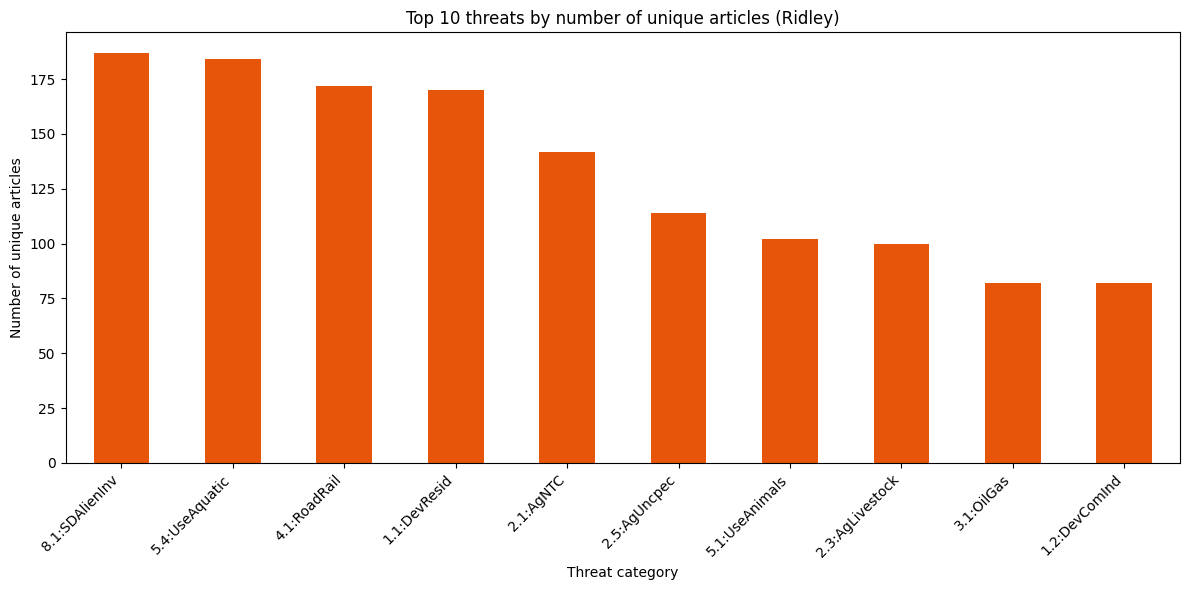

Saved: slide_threat_top10_vertical_orange.png


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
top10.plot(kind="bar", color="#E6550A")
plt.ylabel("Number of unique articles")
plt.xlabel("Threat category")
plt.title("Top 10 threats by number of unique articles (Ridley)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("slide_threat_top10_vertical_orange.png", dpi=300)
plt.show()

print("Saved: slide_threat_top10_vertical_orange.png")


### Optional: articles per year (Ridley)

Simple trend table for dashboard and presentation.


In [17]:
year_counts = (ridley_articles
               .groupby("Year")["ArticleID"]
               .nunique()
               .sort_index()
               .reset_index(name="n_articles"))

year_counts.to_csv("ridley_articles_per_year.csv", index=False)
print("Saved: ridley_articles_per_year.csv")


Saved: ridley_articles_per_year.csv
